# MLE: Interactivity, Real-World Cases & 3D Visualizations

In this notebook, we:

- add **interactive sliders** to explore MLE visually
- find **advanced case studies** (e.g., drug discovery & disease prevalence)
- introduce **3D likelihood surfaces** to understand how MLE works for multiple parameters

**MLE in action = deep understanding + real-world power**

## Interactive Coin Flip MLE
Use sliders to change number of trials and heads count, and watch the likelihood curve update!

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def plot_likelihood(n, k):
    p_values = np.linspace(0.01, 0.99, 200)
    likelihoods = (p_values ** k) * ((1 - p_values) ** (n - k))
    plt.figure(figsize=(8,5))
    plt.plot(p_values, likelihoods)
    plt.title(f'Likelihood Curve (Heads={k}, Trials={n})')
    plt.xlabel('Probability of Heads (p)')
    plt.ylabel('Likelihood')
    plt.axvline(p_values[np.argmax(likelihoods)], color='red', linestyle='--', label=f'MLE p = {p_values[np.argmax(likelihoods)]:.2f}')
    plt.legend()
    plt.show()

widgets.interact(plot_likelihood, n=widgets.IntSlider(10, 1, 50), k=widgets.IntSlider(5, 0, 50))

interactive(children=(IntSlider(value=10, description='n', max=50, min=1), IntSlider(value=5, description='k',…

<function __main__.plot_likelihood(n, k)>

## Drug Discovery: Joint MLE of μ and σ
We simulate IC50 values and estimate **both mean and std deviation** using MLE, visualized in **3D**.

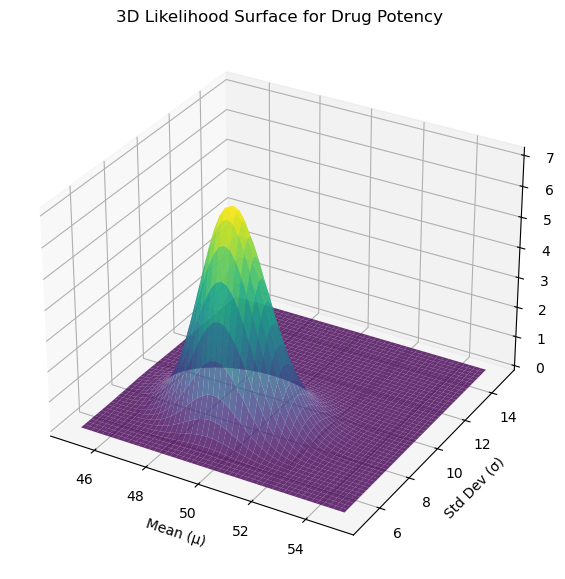

In [7]:
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

# Simulate data
np.random.seed(1)
true_mu, true_sigma = 50, 8
sample = np.random.normal(true_mu, true_sigma, 40)

# Grid
mu_vals = np.linspace(45, 55, 50)
sigma_vals = np.linspace(5, 15, 50)
Mu, Sigma = np.meshgrid(mu_vals, sigma_vals)
Likelihood = np.zeros_like(Mu)

for i in range(Mu.shape[0]):
    for j in range(Mu.shape[1]):
        Likelihood[i, j] = np.prod(norm.pdf(sample, loc=Mu[i, j], scale=Sigma[i, j]))

# 3D Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Mu, Sigma, Likelihood, cmap='viridis', alpha=0.8)
ax.set_xlabel('Mean (μ)')
ax.set_ylabel('Std Dev (σ)')
ax.set_zlabel('Likelihood')
ax.set_title('3D Likelihood Surface for Drug Potency')
plt.show()

## Real-World: Estimating Disease Prevalence

Suppose a disease test returns 5 positives out of 200 people. We estimate the true prevalence (probability of disease).

### Likelihood:

$$ L(p) = \binom{n}{k} p^k (1 - p)^{n - k} $$

We visualize how the MLE adjusts as sample size and positive cases change.

In [10]:
def disease_mle(n, k):
    p_values = np.linspace(0.001, 0.2, 200)
    likelihoods = (p_values ** k) * ((1 - p_values) ** (n - k))
    plt.figure(figsize=(8,5))
    plt.plot(p_values, likelihoods)
    plt.title(f'Disease Prevalence Likelihood (Positives={k}, Total={n})')
    plt.xlabel('Prevalence (p)')
    plt.ylabel('Likelihood')
    plt.axvline(p_values[np.argmax(likelihoods)], color='purple', linestyle='--', label=f'MLE p = {p_values[np.argmax(likelihoods)]:.3f}')
    plt.legend()
    plt.show()

widgets.interact(disease_mle, n=widgets.IntSlider(200, 50, 500), k=widgets.IntSlider(5, 0, 50))

interactive(children=(IntSlider(value=200, description='n', max=500, min=50), IntSlider(value=5, description='…

<function __main__.disease_mle(n, k)>

## Math Recap: Joint MLE
For Normal data:

$$ L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2 \sigma^2} \right) $$

The MLE for $\mu$ and $\sigma$ maximizes this over both parameters.

**Visualization**: In the 3D plot, the peak is where both $\mu$ and $\sigma$ best explain the data.

## Final Takeaways
- **Interactive sliders** help explore likelihoods live
- **3D visualization** reveals how MLE works when estimating multiple parameters
- **Case studies** in drug discovery and disease prevalence show **real-world relevance**

**MLE = powerful + practical + visualized**